**<font color=skyblue>Facenet-PyTorch Demo</font>**

- facenet-PyTorch 基本做法: detected by MTCNN, encoded by FaceNet Model: InceptionResnetV1
- Detect faces and show the image with bounding boxes: MTCNN.detect()
- Show the detected (bounding) faces and save as files.
- Show the extracted (cropped, aligned) faces and save as files
- Easy save for all afces detected in a single image and a batch of images.
- 比較兩張臉孔是否為同一人
- face clustering

source: https://medium.com/@danushidk507/facenet-pytorch-pretrained-pytorch-face-detection-mtcnn-and-facial-recognition-b20af8771144
- need: pip install facenet-pytorch

參考講義：https://ntpuccw.blog/sml-lesson-10-%e4%bd%bf%e7%94%a8-pytorch-%e7%9a%84%e7%94%a2%e5%93%81%ef%bc%9afacenet/



<hr>
<font color=yellow>facenet-PyTorch 基本做法</font>

- Do face detection: MTCNN(Multi-task Cascaded Convolutional Networks) 
- Load pre-trained FaceNet Model: InceptionResnetV1
- Extract embeddings (feature vector 1x512) of an image with multiple faces.


<font color=yellow>Import Packages</font>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from torchvision import transforms
from facenet_pytorch import MTCNN, InceptionResnetV1


/Users/joyce/Desktop/淺度機器學習/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<font color=yellow>Load pre-trained models</font>: detect faces and convert to embeddings

- <font color=skyblue>MTCNN</font> (Multi-task Cascaded Convolutional Networks): a face detection 
model that detects faces in an image and returns their bounding boxes.
- <font color=skyblue>InceptionResnetV1</font>: a face recognition model that takes aligned face images
as input and outputs a 512-dimensional embedding vector for each face.

In [3]:
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# print('Running on device: {}'.format(device))

# Initialize MTCNN for face detection
mtcnn = MTCNN(keep_all=True)
# mtcnn = MTCNN(keep_all=True, device=device)
# Load pre-trained FaceNet model
resnet = InceptionResnetV1(pretrained='casia-webface').eval()

# Load an image containing faces
imgfile = "pictures/abba.png" # 1024x682x3
img = Image.open(imgfile).convert("RGB")

# Detect faces in the image
boxes, _ = mtcnn.detect(img) # boxes: [[x1, y1, x2, y2], ...] the positions of faces in the image
print("There are {} faces in the image.".format(len(boxes)))
# If faces are detected, extract embeddings
if boxes is not None:
    aligned = mtcnn(img) # aligned: torch.Size([n, 3, 160, 160]) where n is the number of detected faces
    embeddings = resnet(aligned).detach() # embeddings: torch.Size([n, 512])
"""  
detach(): To stop tracking the computation history of the embeddings obtained 
from the resnet model, making them simple tensors that do not 
require gradients. This is typically done during inference to 
optimize performance.
"""

print(embeddings.shape) # torch.Size([1, 512])
print(embeddings[0][:10]) 


100%|██████████| 111M/111M [00:03<00:00, 31.6MB/s] 


There are 4 faces in the image.
torch.Size([4, 512])
tensor([-0.0565, -0.0283, -0.0517,  0.0093,  0.0011,  0.0354, -0.0420, -0.0708,
        -0.0112,  0.0346])


In [4]:
help(MTCNN)

Help on class MTCNN in module facenet_pytorch.models.mtcnn:

class MTCNN(torch.nn.modules.module.Module)
 |  MTCNN(image_size=160, margin=0, min_face_size=20, thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True, select_largest=True, selection_method=None, keep_all=False, device=None)
 |  
 |  MTCNN face detection module.
 |  
 |  This class loads pretrained P-, R-, and O-nets and returns images cropped to include the face
 |  only, given raw input images of one of the following types:
 |      - PIL image or list of PIL images
 |      - numpy.ndarray (uint8) representing either a single image (3D) or a batch of images (4D).
 |  Cropped faces can optionally be saved to file
 |  also.
 |  
 |  Keyword Arguments:
 |      image_size {int} -- Output image size in pixels. The image will be square. (default: {160})
 |      margin {int} -- Margin to add to bounding box, in terms of pixels in the final image. 
 |          Note that the application of the margin differs slightly from the 

<font color=yellow>偵測一張照片上的所有人臉並框起來</font> 

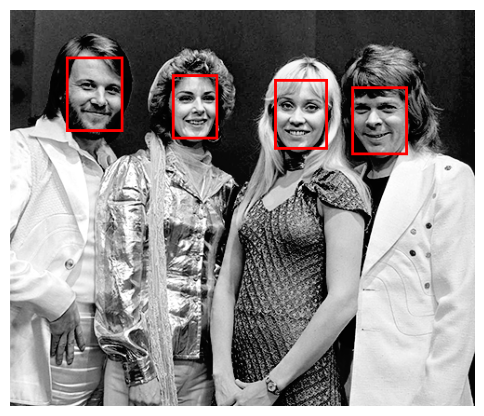

There are 4 faces in the image.


In [5]:
# Initialize MTCNN for face detection
mtcnn = MTCNN() # keep_all=False, the default value

# Load an image containing faces
imgfile = "pictures/abba.png" # 1024x682x3
img = Image.open(imgfile).convert("RGB")

# Detect faces in the image
boxes, _ = mtcnn.detect(img) # although keep_all=False, the default value, boxes will contain the bounding box coordinates of all detected faces. 

# If faces are detected, 'boxes' will contain the bounding box coordinates
if boxes is not None:
    for box in boxes:
        # Draw bounding boxes on the image
        draw = ImageDraw.Draw(img) # Create a drawing context for the image
        draw.rectangle(box.tolist(), outline='red', width=3)

# Display the image with detected faces
plt.figure(figsize=(6, 6))  # Optional: specify the figure size
plt.imshow(img)
plt.axis('off')  # Optional: remove the axis
plt.show()
print("There are {} faces in the image.".format(len(boxes)))

# Save the image with detected faces
# img.save("pictures/face_test_detected.jpg") # Save the image by PIL

<font color=yellow>Show and Save</font>

- Show the detected (bounding) faces and save as files.
- Show the extracted (cropped, aligned) faces and save as files.

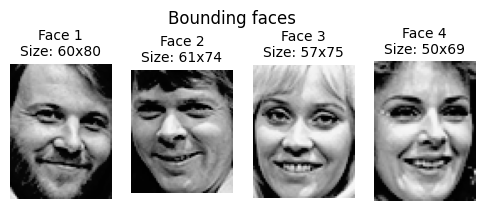

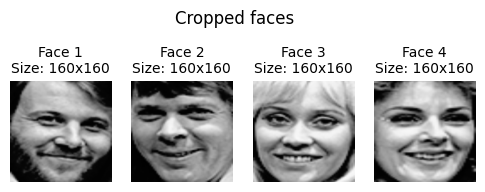

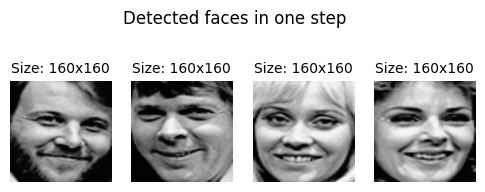

In [20]:
# Initialize MTCNN for face detection
mtcnn = MTCNN(keep_all=True, post_process=False) # post_process=False: no need to post-process the bounding boxes
imgfile = "pictures/abba.png" # 1024x682x3
img = Image.open(imgfile).convert("RGB") # Load the image and convert it to RGB format
boxes, probs, points = mtcnn.detect(img, landmarks=True) # Detect faces and facial landmarks in the image
''' 
Extract and align faces from the image based on the detected bounding boxes. 
The aligned faces are returned as a list of PIL Images. save_path=None 
means that the extracted faces will not be saved to disk, but will be 
returned as PIL Image objects in the aligned_faces list.
'''
aligned_faces = mtcnn.extract(img, boxes, save_path=None) 

# Display the bounding faces
fig, axes = plt.subplots(1, len(aligned_faces), figsize=(6, 4))
# If faces are detected, 'boxes' will contain the bounding boxes
if boxes is not None:
    for i, box in enumerate(boxes):
        # Crop the face from the image using the bounding box
        face_img = img.crop(box)
        face_img.save(f'pictures/bounding_faces_{i+1}.png')
        # Display the cropped face
        if len(aligned_faces) > 1:
            axes[i].imshow(face_img)
            axes[i].axis('off')
            # find the image size from  face_img.size, which is (width, height)
            image_size = face_img.size
            axes[i].set_title(f"Face {i+1}\nSize: {image_size[0]}x{image_size[1]}", fontsize=10)
        else:
            axes.imshow(face_img)
            axes.axis('off')
        
fig.suptitle(f"Bounding faces ", x=0.5, y=0.8)
plt.show()

'''
The mtcnn.extract() function returns cropped faces that are 
aligned based on the facial landmarks. This means that the 
faces are rotated so that the line between the eyes is horizontal. 
This is useful for facial recognition tasks, but it can make the 
faces look weird if they were tilted in the original image. 
'''
# Display the cropped(extracted) faces
fig, axes = plt.subplots(1, len(aligned_faces), figsize=(6, 4))
# If faces are detected, 'aligned_faces' will contain the cropped faces
if aligned_faces is not None:
    for i, face in enumerate(aligned_faces):
        # face_img = face.permute(1, 2, 0).int().numpy()
        # Convert the PyTorch tensor to a PIL Image
        face_img = transforms.ToPILImage()(face/255).convert("RGB")
        face_img.save(f'pictures/cropped_faces_{i+1}.png')
        if len(aligned_faces) > 1:
            # axes[i].imshow(face.permute(1, 2, 0).int().numpy())
            axes[i].imshow(face_img)
            axes[i].axis('off')
                # find the image size from  face_img.size, which is (width, height)
            image_size = face_img.size
            axes[i].set_title(f"Face {i+1}\nSize: {image_size[0]}x{image_size[1]}", fontsize=10)
        else:
            axes.imshow(face_img)
            axes.axis('off')
# want to display the title in the middle of the figure
fig.suptitle("Cropped faces", x=0.5, y=0.8)
# plt.title("Cropped faces")
plt.show()

# Detect face and extract the aligned faces in one step
faces = mtcnn(img)
# Visualize
fig, axes = plt.subplots(1, len(faces), figsize=(6, 4))
for face, ax in zip(faces, axes):
    ax.imshow(face.permute(1, 2, 0).int().numpy())
    ax.axis('off')
    ax.set_title(f"Size: {face.shape[1]}x{face.shape[2]}", fontsize=10)
fig.suptitle("Detected faces in one step", x=0.5, y=0.8)
plt.show()

<font color=yellow>Easy save for all afces detected in a signle image</font>

When multiple faces are detected in a single image, additional faces are each saved with an incremental integer appended to the end of the save path (e.g., '{videoname}_{frame}.jpg' and '{videoname}_{frame}_1.jpg')

In [24]:
# save each face as a file in a single image
mtcnn(img, save_path='pictures/single_image.jpg');

<font color=yellow>比較兩張臉孔是否為同一人</font>

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

# Initialize MTCNN for face detection
mtcnn = MTCNN()

# Load pre-trained Inception ResNet model
resnet = InceptionResnetV1(pretrained='casia-webface').eval()

# Load two face images to be verified
imgfile1 = "pictures/afghan_girl_2.jpg"
imgfile2 = "pictures/afghan_girl_3.jpg"
# imgfile1 = "pictures/Lenna.png"
# imgfile2 = "pictures/Lenna_old_hat.png"
img1 = Image.open(imgfile1).convert("RGB") # convert to RGB to avoid error
img2 = Image.open(imgfile2).convert("RGB")

# Detect faces and extract embeddings
faces1, _ = mtcnn.detect(img1)
faces2, _ = mtcnn.detect(img2)

if faces1 is not None and faces2 is not None:
    aligned1 = mtcnn(img1)
    aligned2 = mtcnn(img2)
    embeddings1 = resnet(aligned1.unsqueeze(0)).detach()
    embeddings2 = resnet(aligned2.unsqueeze(0)).detach()
    
    # Calculate the Euclidean distance between embeddings
    distance_1 = (embeddings1 - embeddings2).norm().item()
    distance_2 = euclidean_distances(embeddings1, embeddings2)[0][0]
    print("Euclidean distance between embeddings: {:.4f}".format(distance_1))
    print("Euclidean distance between embeddings (sklearn): {:.4f}".format(distance_2))
    # Calculate the cosine similarity between embeddings
    distance_3 = cosine_similarity(embeddings1, embeddings2)[0][0]
    print("By Cosine similarity: {:.4f}".format(distance_3))

    if distance_1 < 1.0:  # You can adjust the threshold for verification
        print("Same person")
    else:
        print("Different persons")

Euclidean distance between embeddings: 1.3401
Euclidean distance between embeddings (sklearn): 1.3401
By Cosine similarity: 0.1020
Different persons


<font color=yellow>Face clustering</font>

Labelling a group of images according to their embeddings.

In [ ]:
from sklearn.cluster import DBSCAN
import glob as glob

# Initialize MTCNN for face detection
mtcnn = MTCNN()

# Load pre-trained Inception ResNet model
resnet = InceptionResnetV1(pretrained='casia-webface').eval()

# Load a collection of face images
all_paths = []
IMGPATH = ["pictures/"]
for img_paths in IMGPATH:
        all_paths.extend(glob.glob(f"{img_paths}/*"))
# img_paths = ['path_to_image1.jpg', 'path_to_image2.jpg', ...]
print(f"Creating embeddings for {len(all_paths)} images")
# Initialize lists to store face embeddings
embeddings = []

for img_path in all_paths:
    img = Image.open(img_path).convert("RGB")
    faces, _ = mtcnn.detect(img)
    if faces is not None:
        aligned = mtcnn(img)
        face_embeddings = resnet(aligned.unsqueeze(0)).detach()
        embeddings.append(face_embeddings.numpy())
        print(img_path, face_embeddings.shape)
# Perform clustering using DBSCAN
embeddings = np.vstack(embeddings)
clustering = DBSCAN(eps=0.5, min_samples=2).fit(embeddings)

# 'clustering.labels_' contains cluster labels for each face
print(clustering.labels_)
print(len(clustering.labels_))
print(clustering.labels_.shape)